In [ ]:
#PARTE 1- entrega 2 

# Setup e imports
import sys, os

ruta_src = os.path.abspath(os.path.join("..", "src"))

if ruta_src not in sys.path:
    sys.path.append(ruta_src)

#se importa directamente a los módulos
from calculo_rendimientos import calculate_returns
from analisis_periodos import identify_daily_shocks
from visualizaciones import plot_price_evolution_with_intervals

GMEXICO_PATH = os.path.abspath(os.path.join("..", "datos_historicos", "gmexico_prices.csv"))
IPC_PATH = os.path.abspath(os.path.join("..", "datos_historicos", "ipc_prices.csv"))

In [ ]:
# Rendimientos y shocks

df_gmexico = calculate_returns(GMEXICO_PATH)
df_ipc     = calculate_returns(IPC_PATH)

shocks = identify_daily_shocks(df_gmexico, threshold=0.15)
print(f"{len(shocks)} shocks diarios (±15%) entre {df_gmexico.index.min().date()} y {df_gmexico.index.max().date()}")
df_gmexico.tail()

5 shocks diarios (±15%) entre 2000-01-04 y 2026-09-14


,adj_close,simple_return,log_return,cumulative_return,daily_return
Date,,,,,
2026-09-08,229.559998,0.025875,0.025546,116.658060,0.025875
2026-09-09,228.500000,-0.004618,-0.004628,116.119389,-0.004618
2026-09-10,218.339996,-0.044464,-0.045483,110.956267,-0.044464
2026-09-11,218.300003,-0.000183,-0.000183,110.935943,-0.000183
2026-09-14,213.910004,-0.020110,-0.020315,108.705029,-0.020110


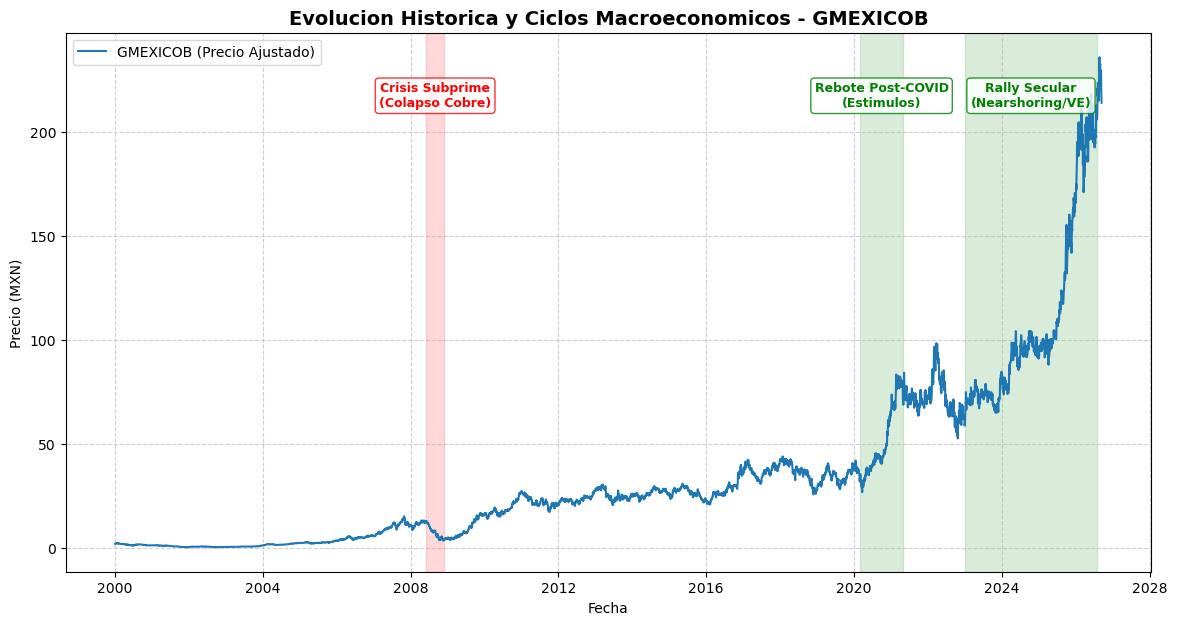

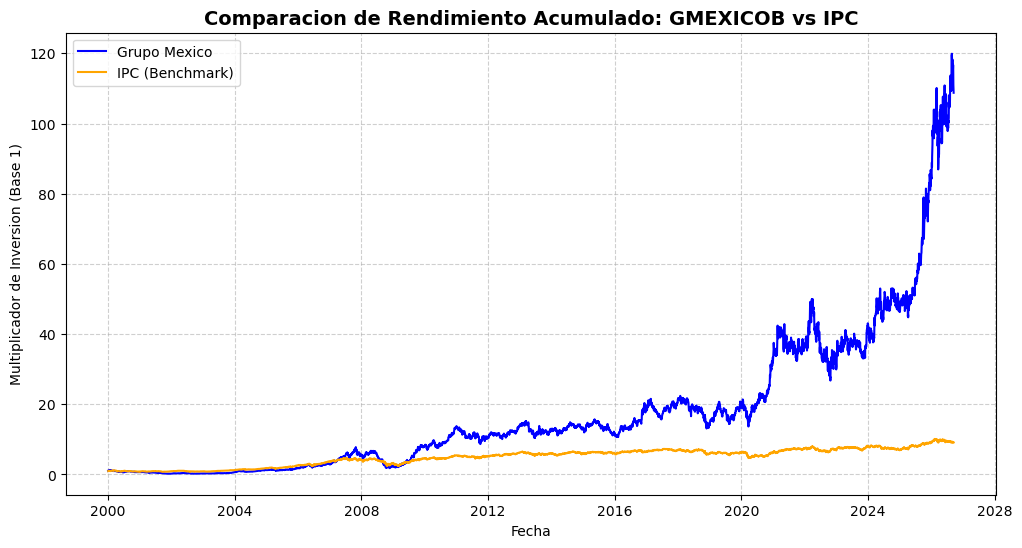

In [ ]:
# Gráficos

# las dos funciones de graficación
from visualizaciones import plot_price_evolution_with_intervals, plot_cumulative_comparison

# primera gráfica
plot_price_evolution_with_intervals(df_gmexico, "GMEXICOB", "evolucion_precio_intervalos")

# alineación de datos y cálculo de rendimiento acumulado
df_gmexico_aligned, df_ipc_aligned = df_gmexico.align(df_ipc, join='inner', axis=0)
df_gmexico_aligned['cumulative_return'] = (1 + df_gmexico_aligned['simple_return']).cumprod()
df_ipc_aligned['cumulative_return']     = (1 + df_ipc_aligned['simple_return']).cumprod()

# segunda gráfica
plot_cumulative_comparison(df_gmexico_aligned, df_ipc_aligned, "comparacion_acumulada_ipc")

In [12]:
# Tabla de Períodos Significativos

# asegurar que el índice de df_gmexico sea DatetimeIndex y esté ordenado
if not isinstance(df_gmexico.index, pd.DatetimeIndex):
    df_gmexico.index = pd.to_datetime(df_gmexico.index)
df_gmexico = df_gmexico.sort_index()


def precio_en(df, fecha):
    fecha = pd.to_datetime(fecha)
    sub = df.loc[:fecha]

    # si la fecha es anterior al inicio de los datos, toma el primer registro disponible
    if sub.empty:
        return df.iloc[0]["adj_close"], df.index[0]

    return sub.iloc[-1]["adj_close"], sub.index[-1]


# Definición de periodos
periodos_significativos = [
    {
        "inicio": "2000-01-03",
        "fin": "2003-04-01",
        "patron": "Consolidación en mínimos (post dot-com, cobre débil)",
    },
    {
        "inicio": "2003-04-01",
        "fin": "2008-05-30",
        "patron": "Canal alcista (superciclo de commodities / boom de China)",
    },
    {
        "inicio": "2008-05-30",
        "fin": "2008-11-28",
        "patron": "Colapso (Crisis Subprime / desplome del cobre)",
    },
    {
        "inicio": "2008-11-28",
        "fin": "2011-04-01",
        "patron": "Recuperación en V (estímulos fiscales y monetarios globales)",
    },
    {
        "inicio": "2011-04-01",
        "fin": "2015-12-31",
        "patron": "Consolidación bajista (fin del superciclo, dólar fuerte)",
    },
    {
        "inicio": "2015-12-31",
        "fin": "2018-01-15",
        "patron": "Recuperación (repunte del precio del cobre)",
    },
    {
        "inicio": "2018-01-15",
        "fin": "2020-03-23",
        "patron": (
            "Caída / consolidación (guerra comercial EU-China + shock COVID)"
        ),
    },
    {
        "inicio": "2020-03-23",
        "fin": "2021-04-30",
        "patron": "Rebote post-COVID (estímulos, reapertura económica)",
    },
    {
        "inicio": "2021-04-30",
        "fin": "2022-12-30",
        "patron": (
            "Consolidación (alza de tasas globales, corrección del cobre)"
        ),
    },
    {
        "inicio": "2022-12-30",
        "fin": df_gmexico.index.max().strftime("%Y-%m-%d"),
        "patron": (
            "Rally secular (nearshoring, superciclo del cobre, aranceles"
            " EE.UU.)"
        ),
    },
]

filas = []
for p in periodos_significativos:
    p0, d0 = precio_en(df_gmexico, p["inicio"])
    p1, d1 = precio_en(df_gmexico, p["fin"])
    dias = (d1 - d0).days
    filas.append({
        "Fecha inicio": d0.date(),
        "Fecha fin": d1.date(),
        "Precio inicio": round(p0, 2),
        "Precio fin": round(p1, 2),
        "Magnitud (%)": round((p1 / p0 - 1) * 100, 1),
        "Duración (días)": dias,
        "Duración (meses)": round(dias / 30.44, 1),
        "Patrón visual": p["patron"],
    })

tabla_periodos = pd.DataFrame(filas)
tabla_periodos

,Fecha inicio,Fecha fin,Precio inicio,Precio fin,Magnitud (%),Duración (días),Duración (meses),Patrón visual
0,2000-01-04,2003-04-01,1.94,0.57,-70.6,1183,38.9,"Consolidación en mínimos (post dot-com, cobre ..."
1,2003-04-01,2008-05-30,0.57,12.60,2105.1,1886,62.0,Canal alcista (superciclo de commodities / boo...
2,2008-05-30,2008-11-28,12.60,4.33,-65.6,182,6.0,Colapso (Crisis Subprime / desplome del cobre)
3,2008-11-28,2011-04-01,4.33,24.24,459.1,854,28.1,Recuperación en V (estímulos fiscales y moneta...
4,2011-04-01,2015-12-31,24.24,23.01,-5.1,1735,57.0,"Consolidación bajista (fin del superciclo, dól..."
5,2015-12-31,2018-01-15,23.01,42.88,86.4,746,24.5,Recuperación (repunte del precio del cobre)
6,2018-01-15,2020-03-23,42.88,26.85,-37.4,798,26.2,Caída / consolidación (guerra comercial EU-Chi...
7,2020-03-23,2021-04-30,26.85,70.26,161.7,403,13.2,"Rebote post-COVID (estímulos, reapertura econó..."
8,2021-04-30,2022-12-30,70.26,58.85,-16.2,609,20.0,"Consolidación (alza de tasas globales, correcc..."
9,2022-12-30,2026-09-14,58.85,213.91,263.5,1354,44.5,"Rally secular (nearshoring, superciclo del cob..."


In [14]:
# tabla en Markdown
print(tabla_periodos.to_markdown(index=False))

| Fecha inicio   | Fecha fin   |   Precio inicio |   Precio fin |   Magnitud (%) |   Duración (días) |   Duración (meses) | Patrón visual                                                       |
|:---------------|:------------|----------------:|-------------:|---------------:|------------------:|-------------------:|:--------------------------------------------------------------------|
| 2000-01-04     | 2003-04-01  |            1.94 |         0.57 |          -70.6 |              1183 |               38.9 | Consolidación en mínimos (post dot-com, cobre débil)                |
| 2003-04-01     | 2008-05-30  |            0.57 |        12.6  |         2105.1 |              1886 |               62   | Canal alcista (superciclo de commodities / boom de China)           |
| 2008-05-30     | 2008-11-28  |           12.6  |         4.33 |          -65.6 |               182 |                6   | Colapso (Crisis Subprime / desplome del cobre)                      |
| 2008-11-28     | 2011-04-01 

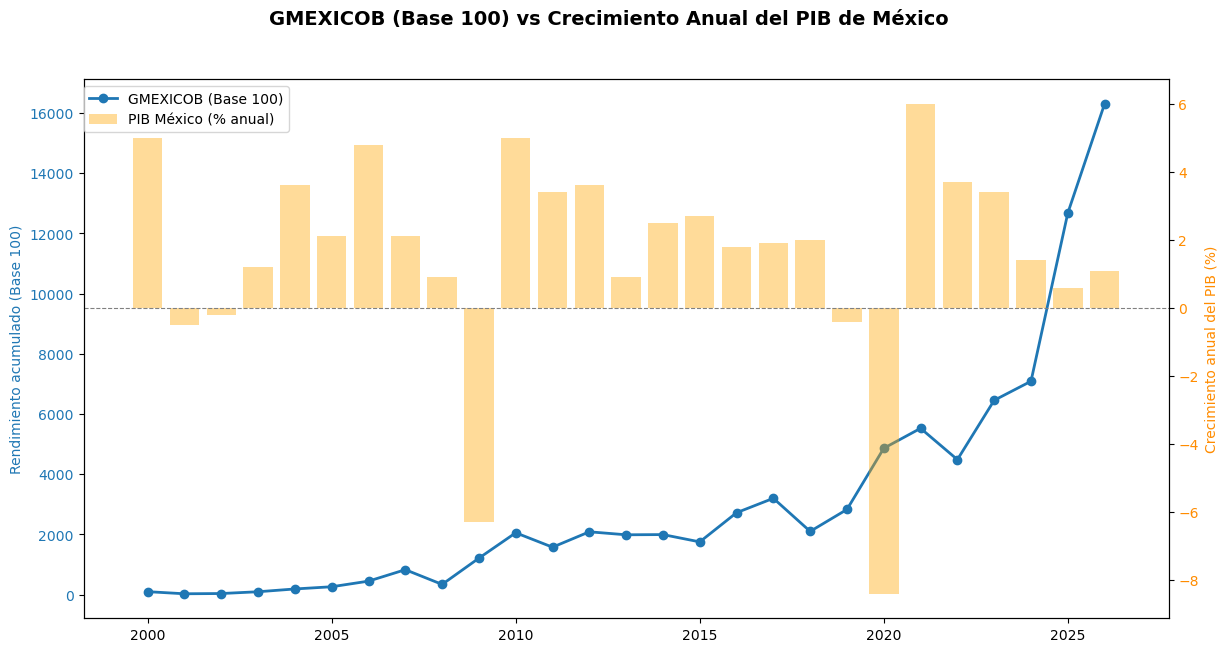

In [16]:
#PARTE 2- entrega 2
 
#Gráfico doble eje

from datos_macro import get_pib_series
pib = get_pib_series()

annual_price = df_gmexico['adj_close'].resample('YE').last()
base100 = (annual_price / annual_price.iloc[0]) * 100
base100.index = base100.index.year

fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.plot(base100.index, base100.values, color='#1f77b4', linewidth=2, marker='o', label='GMEXICOB (Base 100)')
ax1.set_ylabel('Rendimiento acumulado (Base 100)', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

ax2 = ax1.twinx()
ax2.bar(pib.index, pib.values, color='orange', alpha=0.4, label='PIB México (% anual)')
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Crecimiento anual del PIB (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

fig.suptitle('GMEXICOB (Base 100) vs Crecimiento Anual del PIB de México', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.savefig(os.path.join("..", "graficas", "gmexico_vs_pib.png"), dpi=300, bbox_inches='tight')
plt.show()

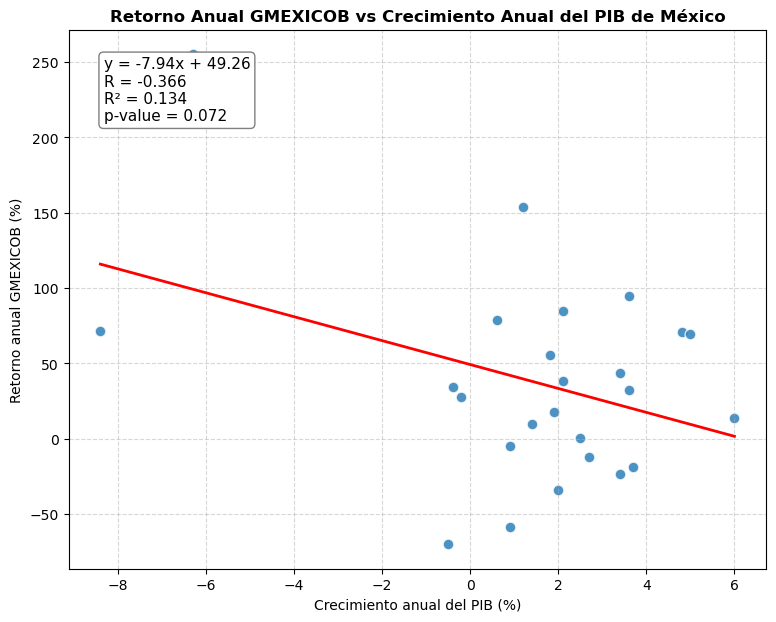

R = -0.366  |  R² = 0.134  |  p-value = 0.072


In [17]:
# Scatter + regresión 

from scipy import stats

annual_ret = annual_price.pct_change() * 100
annual_ret.index = annual_ret.index.year

datos = pd.DataFrame({'retorno_gmexico': annual_ret, 'pib_crecimiento': pib}).dropna()
datos = datos.drop(index=2026, errors='ignore')  # 2026 aún no cierra, no es comparable

slope, intercept, r, p_value, std_err = stats.linregress(datos['pib_crecimiento'], datos['retorno_gmexico'])
r2 = r**2

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(datos['pib_crecimiento'], datos['retorno_gmexico'], color='#1f77b4', s=60, alpha=0.8, edgecolor='white')
x_line = np.linspace(datos['pib_crecimiento'].min(), datos['pib_crecimiento'].max(), 50)
ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=2)

signo = '+' if intercept >= 0 else '-'
texto = f"y = {slope:.2f}x {signo} {abs(intercept):.2f}\nR = {r:.3f}\nR² = {r2:.3f}\np-value = {p_value:.3f}"
ax.text(0.05, 0.95, texto, transform=ax.transAxes, va='top', fontsize=11,
        bbox=dict(boxstyle="round", fc="white", ec="gray"))

ax.set_title('Retorno Anual GMEXICOB vs Crecimiento Anual del PIB de México', fontweight='bold')
ax.set_xlabel('Crecimiento anual del PIB (%)')
ax.set_ylabel('Retorno anual GMEXICOB (%)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join("..", "graficas", "scatter_gmexico_pib.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"R = {r:.3f}  |  R² = {r2:.3f}  |  p-value = {p_value:.3f}")